In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder


In [16]:

df = pd.read_csv("pbp2026.csv")

print("="*80)
print("FIRST 5 ROWS")
print("="*80)
print(df.head())

print("\n" + "="*80)
print("LAST 5 ROWS")
print("="*80)
print(df.tail())

print("\nDataset Shape :", df.shape)


FIRST 5 ROWS
     gameid  period        clock  h_pts  a_pts team  playerid       player  \
0  22500001       1  PT12M00.00S    0.0    0.0  NaN         0          NaN   
1  22500001       1  PT12M00.00S    NaN    NaN  OKC   1631096  C. Holmgren   
2  22500001       1  PT11M36.00S    NaN    NaN  HOU   1630578    A. Sengun   
3  22500001       1  PT11M31.00S    NaN    NaN  OKC   1641717   C. Wallace   
4  22500001       1  PT11M26.00S    2.0    0.0  OKC   1631096  C. Holmgren   

          type             subtype  result      x      y  dist  \
0       period               start     NaN    0.0    0.0   0.0   
1    Jump Ball                 NaN     NaN    0.0    0.0   0.0   
2  Missed Shot           Jump Shot  Missed -179.0  179.0  25.0   
3      Rebound             Unknown     NaN    0.0    0.0   0.0   
4    Made Shot  Cutting Layup Shot    Made    0.0   13.0   1.0   

                                                desc  season  
0                  Start of 1st Period (7:44 PM EST)    20

In [17]:
print("="*80)
print("MISSING VALUES")
print("="*80)

print(df.isnull())


MISSING VALUES
        gameid  period  clock  h_pts  a_pts   team  playerid  player   type  \
0        False   False  False  False  False   True     False    True  False   
1        False   False  False   True   True  False     False   False  False   
2        False   False  False   True   True  False     False   False  False   
3        False   False  False   True   True  False     False   False  False   
4        False   False  False  False  False  False     False   False  False   
...        ...     ...    ...    ...    ...    ...       ...     ...    ...   
622184   False   False  False  False  False  False     False   False  False   
622185   False   False  False  False  False  False     False   False  False   
622186   False   False  False  False  False  False     False    True  False   
622187   False   False  False  False  False   True     False    True  False   
622188   False   False  False  False  False   True     False    True  False   

        subtype  result      x      

In [18]:
print("="*80)
print("COUNT OF MISSING VALUES")
print("="*80)

print(df.isnull().sum())


COUNT OF MISSING VALUES
gameid           0
period           0
clock            0
h_pts       458774
a_pts       458774
team         52123
playerid         0
player       51021
type         32511
subtype      99303
result      402841
x             1638
y             1638
dist          1636
desc             0
season           0
dtype: int64


In [19]:
print("="*80)
print("REPLACING MISSING VALUES")
print("="*80)

# Numerical Columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Categorical Columns
categorical_cols = df.select_dtypes(include="str").columns

# Fill Numerical Missing Values with Mean
# (h_pts / a_pts / x / y / dist are only populated on scoring/shot events)
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill Categorical Missing Values with Mode
# (team / player / type / subtype / result are blank for period start/end
#  and other non-play events)
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values After Filling\n")
print(df.isnull().sum())


REPLACING MISSING VALUES
Missing Values After Filling

gameid      0
period      0
clock       0
h_pts       0
a_pts       0
team        0
playerid    0
player      0
type        0
subtype     0
result      0
x           0
y           0
dist        0
desc        0
season      0
dtype: int64


In [20]:

print("="*80)
print("DUPLICATE RECORDS")
print("="*80)

duplicates = df.duplicated().sum()

print("Duplicate Rows Before Removal :", duplicates)

df.drop_duplicates(inplace=True)

print("Duplicate Rows After Removal :", df.duplicated().sum())

print("Dataset Shape :", df.shape)


DUPLICATE RECORDS
Duplicate Rows Before Removal : 159
Duplicate Rows After Removal : 0
Dataset Shape : (622030, 16)


OUTLIER DETECTION
period : 0 Outliers
h_pts : 163413 Outliers
a_pts : 163413 Outliers
x : 212149 Outliers
y : 117871 Outliers
dist : 119333 Outliers


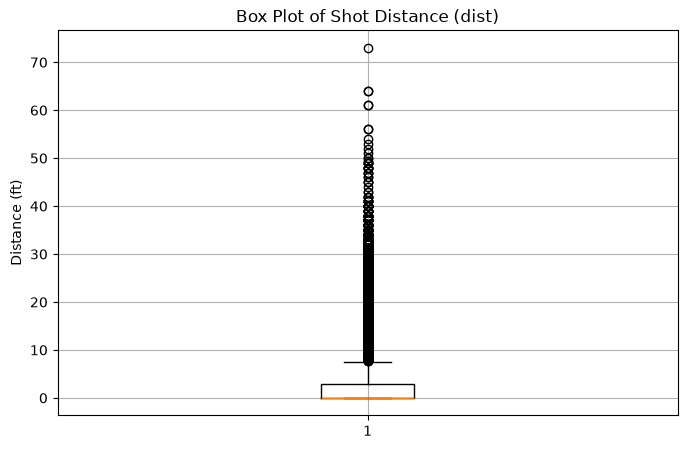

In [21]:
print("="*80)
print("OUTLIER DETECTION")
print("="*80)

numeric_columns = ["period", "h_pts", "a_pts", "x", "y", "dist"]

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} : {len(outliers)} Outliers")


plt.figure(figsize=(8,5))
plt.boxplot(df["dist"])
plt.title("Box Plot of Shot Distance (dist)")
plt.ylabel("Distance (ft)")
plt.grid(True)
plt.show()


MIN-MAX NORMALIZATION
   period     h_pts     a_pts      x         y      dist
0     0.0  0.000000  0.000000  0.500  0.064968  0.000000
1     0.0  0.383935  0.377601  0.500  0.064968  0.000000
2     0.0  0.383935  0.377601  0.142  0.292994  0.342466
3     0.0  0.383935  0.377601  0.500  0.064968  0.000000
4     0.0  0.012739  0.000000  0.500  0.081529  0.013699


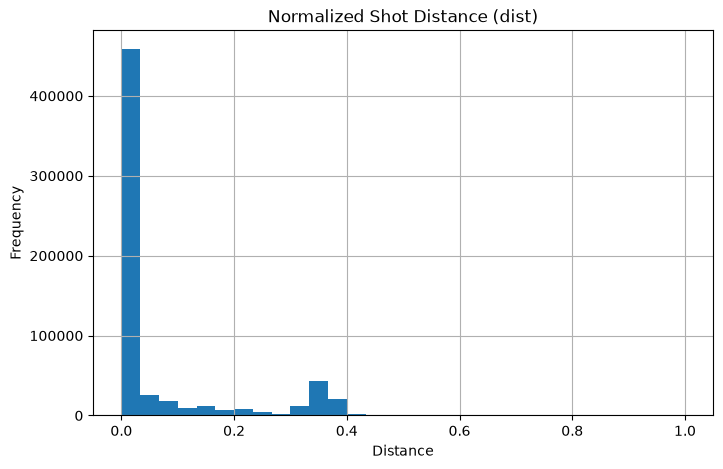

In [22]:

print("="*80)
print("MIN-MAX NORMALIZATION")
print("="*80)

scaler = MinMaxScaler()

columns_to_normalize = [
    "period",
    "h_pts",
    "a_pts",
    "x",
    "y",
    "dist"
]

df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

print(df[columns_to_normalize].head())

# Histogram

plt.figure(figsize=(8,5))
plt.hist(df["dist"], bins=30)
plt.title("Normalized Shot Distance (dist)")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [23]:

print("="*80)
print("LABEL ENCODING")
print("="*80)

label_columns = df.select_dtypes(include="str").columns

encoder = LabelEncoder()

for col in label_columns:
    df[col] = encoder.fit_transform(df[col])

print(df.head())


LABEL ENCODING
     gameid  period  clock     h_pts     a_pts  team  playerid  player  type  \
0  22500001     0.0   1260  0.000000  0.000000     8         0      56    21   
1  22500001     0.0   1260  0.383935  0.377601    20   1631096     133     7   
2  22500001     0.0   1236  0.383935  0.377601    10   1630578      53     9   
3  22500001     0.0   1231  0.383935  0.377601    20   1641717     165    10   
4  22500001     0.0   1226  0.012739  0.000000    20   1631096     133     8   

   subtype  result      x         y      dist    desc  season  
0      160       1  0.500  0.064968  0.000000  233851    2026  
1      140       1  0.500  0.064968  0.000000  108238    2026  
2       80       1  0.142  0.292994  0.342466  153280    2026  
3      140       1  0.500  0.064968  0.000000  249383    2026  
4       24       0  0.500  0.081529  0.013699   88428    2026  


In [24]:
print("="*80)
print("ONE HOT ENCODING")
print("="*80)

onehot_columns = ["team", "type", "result"]

df_onehot = pd.get_dummies(
    df,
    columns=onehot_columns,
    dtype=int
)

print(df_onehot.head())


ONE HOT ENCODING
     gameid  period  clock     h_pts     a_pts  playerid  player  subtype  \
0  22500001     0.0   1260  0.000000  0.000000         0      56      160   
1  22500001     0.0   1260  0.383935  0.377601   1631096     133      140   
2  22500001     0.0   1236  0.383935  0.377601   1630578      53       80   
3  22500001     0.0   1231  0.383935  0.377601   1641717     165      140   
4  22500001     0.0   1226  0.012739  0.000000   1631096     133       24   

       x         y  ...  type_20  type_21  type_22  type_23  type_24  type_25  \
0  0.500  0.064968  ...        0        1        0        0        0        0   
1  0.500  0.064968  ...        0        0        0        0        0        0   
2  0.142  0.292994  ...        0        0        0        0        0        0   
3  0.500  0.064968  ...        0        0        0        0        0        0   
4  0.500  0.081529  ...        0        0        0        0        0        0   

   type_26  type_27  result_0  re

In [25]:
print("="*80)
print("FINAL CLEANED DATASET")
print("="*80)

print(df.head())


FINAL CLEANED DATASET
     gameid  period  clock     h_pts     a_pts  team  playerid  player  type  \
0  22500001     0.0   1260  0.000000  0.000000     8         0      56    21   
1  22500001     0.0   1260  0.383935  0.377601    20   1631096     133     7   
2  22500001     0.0   1236  0.383935  0.377601    10   1630578      53     9   
3  22500001     0.0   1231  0.383935  0.377601    20   1641717     165    10   
4  22500001     0.0   1226  0.012739  0.000000    20   1631096     133     8   

   subtype  result      x         y      dist    desc  season  
0      160       1  0.500  0.064968  0.000000  233851    2026  
1      140       1  0.500  0.064968  0.000000  108238    2026  
2       80       1  0.142  0.292994  0.342466  153280    2026  
3      140       1  0.500  0.064968  0.000000  249383    2026  
4       24       0  0.500  0.081529  0.013699   88428    2026  


In [26]:
print("="*80)
print("DATASET INFORMATION")
print("="*80)

print(df.info())


DATASET INFORMATION
<class 'pandas.DataFrame'>
Index: 622030 entries, 0 to 622188
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   gameid    622030 non-null  int64  
 1   period    622030 non-null  float64
 2   clock     622030 non-null  int64  
 3   h_pts     622030 non-null  float64
 4   a_pts     622030 non-null  float64
 5   team      622030 non-null  int64  
 6   playerid  622030 non-null  int64  
 7   player    622030 non-null  int64  
 8   type      622030 non-null  int64  
 9   subtype   622030 non-null  int64  
 10  result    622030 non-null  int64  
 11  x         622030 non-null  float64
 12  y         622030 non-null  float64
 13  dist      622030 non-null  float64
 14  desc      622030 non-null  int64  
 15  season    622030 non-null  int64  
dtypes: float64(6), int64(10)
memory usage: 80.7 MB
None


In [27]:
print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)

print(df.describe())


STATISTICAL SUMMARY
             gameid         period          clock          h_pts  \
count  6.220300e+05  622030.000000  622030.000000  622030.000000   
mean   2.250061e+07       0.304961     841.039318       0.383934   
std    3.561041e+02       0.226024     286.057978       0.114284   
min    2.250000e+07       0.000000       0.000000       0.000000   
25%    2.250030e+07       0.200000     700.000000       0.383935   
50%    2.250061e+07       0.400000     874.000000       0.383935   
75%    2.250092e+07       0.600000    1053.000000       0.383935   
max    2.250123e+07       1.000000    1260.000000       1.000000   

               a_pts           team      playerid         player  \
count  622030.000000  622030.000000  6.220300e+05  622030.000000   
mean        0.377601      13.975493  9.883627e+07     405.282596   
std         0.112692       8.476655  3.837765e+08     255.600385   
min         0.000000       0.000000  0.000000e+00       0.000000   
25%         0.377601       

In [28]:
df.to_csv("pbp2026_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully as \'pbp2026_Cleaned.csv\'")


Cleaned dataset saved successfully as 'pbp2026_Cleaned.csv'
